# Red Neuronal: Feed-Forward Network con PyTorch

## Preprocesamiento para Redes Neuronales

Las redes neuronales tienen requisitos diferentes a los modelos basados en árboles:

- **No pueden manejar NaN**: Las operaciones con tensores requieren valores numéricos
- **Sensibles a la escala**: El gradient descent funciona mejor con entradas normalizadas
- **Pueden aprender patrones de ausencia**: Con características indicadoras explícitas

La estrategia de "Imputación con Ceros y Banderas" aborda estos requisitos:
- Rellena todos los valores numéricos faltantes con 0
- Conserva TODAS las banderas `_measured` como características
- Aplica escalado estándar después de la imputación

La red aprende a interpretar la combinación de (valor=0, measured=False) como "faltante" en lugar de "verdaderamente cero".

## Carga de Datos y Preprocesamiento

In [ ]:
import numpy as npimport torchimport torch.nn as nnfrom torch.utils.data import DataLoader, TensorDatasetfrom sklearn.model_selection import train_test_splitfrom sklearn.preprocessing import LabelEncoderfrom src.data_loader import load_thyroid_data_3_classesfrom src.preprocessing import get_zero_imputation_with_flags_pipelinefrom src.metrics import thyroid_disease_f2_score# conjunto random seeds for reproducibilitytorch.manual_seed(42)np.random.seed(42)

Para datos tabulares de este tamaño, la cross-validación (como se usa en los notebooks 03 y 04) proporciona una estimación de evaluación más estable. Sin embargo, el flujo de trabajo típico de aprendizaje profundo usa una simple división **entrenamiento / validación / prueba** y monitoriza una métrica de validación durante el entrenamiento para seleccionar el mejor checkpoint. Seguimos ese enfoque primero y luego añadimos una comparación con cross-validación al final del notebook.

In [ ]:
X_train_full, X_test, y_train_full, y_test = load_thyroid_data_3_classes(test_size=0.15, random_state=42)# Create a validación conjunto from the entrenamiento datos to monitor during entrenamientoX_train, X_val, y_train, y_val = train_test_split(    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full)print(f"Training:   {len(X_train)} samples")print(f"Validation: {len(X_val)} samples")print(f"Test:       {len(X_test)} samples (held out until final evaluation)")

Training:   6626 samples
Validation: 1170 samples
Test:       1376 samples (held out until final evaluation)


In [ ]:
preprocessor = get_zero_imputation_with_flags_pipeline()X_train_processed = preprocessor.fit_transform(X_train)X_val_processed = preprocessor.transform(X_val)X_test_processed = preprocessor.transform(X_test)print(f"Number of features after preprocessing: {X_train_processed.shape[1]}")

Number of features after preprocessing: 28


In [ ]:
# Encode labels (alphabetical order: hyperthyroid=0, hypothyroid=1, negative=2)label_encoder = LabelEncoder()y_train_encoded = label_encoder.fit_transform(y_train)y_val_encoded = label_encoder.transform(y_val)y_test_encoded = label_encoder.transform(y_test)# Also encode the full entrenamiento conjunto, needed for cross-validación latery_train_full_encoded = label_encoder.transform(y_train_full)print(f"Classes: {label_encoder.classes_}")

Classes: ['hyperthyroid' 'hypothyroid' 'negative']


## Preparación de Datos con PyTorch

In [ ]:
X_train_tensor = torch.tensor(X_train_processed.astype(np.float32))X_val_tensor = torch.tensor(X_val_processed.astype(np.float32))X_test_tensor = torch.tensor(X_test_processed.astype(np.float32))y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)y_val_tensor = torch.tensor(y_val_encoded, dtype=torch.long)y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)print(f"Tensor shapes — X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")

Tensor shapes — X_train: torch.Size([6626, 28]), y_train: torch.Size([6626])


## Arquitectura de ThyroidNet

Diseñamos una red feed-forward simple con:

- **Batch normalization**: Ayuda con la estabilidad del entrenamiento y actúa como regularización
- **Dropout**: Previene el sobreajuste zeroing aleatoriamente activaciones
- **Activaciones ReLU**: No linealidad estándar para capas ocultas
- **Capas progresivamente más pequeñas**: Compresión de características hacia la salida

In [ ]:
class ThyroidNet(nn.Module):        def __init__(self, input_size: int, num_classes: int = 3, dropout_rate: float = 0.3):        super().__init__()                self.network = nn.Sequential(            nn.Linear(input_size, 128),            nn.BatchNorm1d(128),            nn.ReLU(),            nn.Dropout(dropout_rate),                        nn.Linear(128, 64),            nn.BatchNorm1d(64),            nn.ReLU(),            nn.Dropout(dropout_rate),                        nn.Linear(64, 32),            nn.BatchNorm1d(32),            nn.ReLU(),            nn.Dropout(dropout_rate),                        nn.Linear(32, num_classes)        )        def forward(self, x: torch.Tensor) -> torch.Tensor:        return self.network(x)

In [ ]:
n_features = X_train_processed.shape[1]n_classes = len(label_encoder.classes_)# Display the architectureprint(ThyroidNet(n_features, n_classes))

ThyroidNet(
  (network): Sequential(
    (0): Linear(in_features=28, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)


## Configuración del Entrenamiento

For multi-clase clasificación, Usamos `CrossEntropyLoss`. To handle clase imbalance, clase weights are computed inversely proportional to clase frequency — the same principle as `sample_weight` in XGBoost. Without these weights, the large "negative" majority dominates the gradient and El modeloo learns to ignore rare disease classes.We encapsulate the full entrenamiento bucle in a `train_model()` función that:- Computes clase weights automatically from the entrenamiento labels- Tracks entrenamiento/validación pérdida and validación F2 score per epoch- Saves and restores the **best modelo checkpoint** (highest validación F2)This función is reused later in the cross-validación section.

In [ ]:
# Show clase imbalance that motivates clase-weighted pérdida# (train_model() computes these automatically — shown here for illustration)class_counts = np.bincount(y_train_encoded)class_weights_demo = 1.0 / torch.tensor(class_counts, dtype=torch.float)class_weights_demo = class_weights_demo / class_weights_demo.sum() * n_classesprint(f"Class counts (hyperthyroid=0, hypothyroid=1, negative=2): {class_counts}")print(f"Normalized class weights: {class_weights_demo.numpy().round(3)}")print("→ Disease classes receive much higher weight, making their misclassification more costly.")

Class counts (hyperthyroid=0, hypothyroid=1, negative=2): [ 174  482 5970]
Normalized class weights: [2.158 0.779 0.063]
→ Disease classes receive much higher weight, making their misclassification more costly.


## entrenamiento función

We encapsulate the full entrenamiento logic into a single `train_model()` función. This makes the entrenamiento procedure reusable — Vamos a call it once Para el train/val/prueba split below, and again for each fold in the cross-validación comparison.

In [ ]:
def train_model(    X_train_t: torch.Tensor,    y_train_t: torch.Tensor,    X_val_t: torch.Tensor,    y_val_t: torch.Tensor,    n_features: int,    n_classes: int,    num_epochs: int = 100,    batch_size: int = 64,    lr: float = 0.001,    dropout_rate: float = 0.3,) -> tuple[ThyroidNet, list[float], list[float], list[float]]:    """Train ThyroidNet and return (best_model, train_losses, val_losses, val_f2s).    Class weights are computed automatically from y_train_t.    The returned model is already loaded with the best checkpoint (highest val F2).    """    # Compute clase weights from entrenamiento labels (inverted frequency, normalized)    class_counts = np.bincount(y_train_t.numpy())    class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)    class_weights = class_weights / class_weights.sum() * n_classes    model = ThyroidNet(n_features, n_classes, dropout_rate)    criterion = nn.CrossEntropyLoss(weight=class_weights)    optimizer = torch.optim.Adam(model.parameters(), lr=lr)    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)    train_losses: list[float] = []    val_losses: list[float] = []    val_f2s: list[float] = []    best_val_f2 = 0.0    best_model_state = None    for epoch in range(num_epochs):        # entrenamiento phase        model.train()        batch_losses: list[float] = []        for X_batch, y_batch in train_loader:            optimizer.zero_grad()            loss = criterion(model(X_batch), y_batch)            loss.backward()            optimizer.step()            batch_losses.append(loss.item())        train_losses.append(sum(batch_losses) / len(batch_losses))        # validación phase        model.eval()        with torch.no_grad():            fold_val_losses: list[float] = []            preds: list[int] = []            targets: list[int] = []            for X_batch, y_batch in val_loader:                outputs = model(X_batch)                fold_val_losses.append(criterion(outputs, y_batch).item())                preds.extend(outputs.argmax(dim=1).numpy())                targets.extend(y_batch.numpy())        val_losses.append(sum(fold_val_losses) / len(fold_val_losses))        f2 = thyroid_disease_f2_score(np.array(targets), np.array(preds))        val_f2s.append(f2)        if f2 > best_val_f2:            best_val_f2 = f2            best_model_state = model.state_dict().copy()    model.load_state_dict(best_model_state)    return model, train_losses, val_losses, val_f2s

## Train / validación / prueba Split entrenamiento

In [ ]:
model, train_losses, val_losses, val_f2s = train_model(    X_train_tensor, y_train_tensor,    X_val_tensor, y_val_tensor,    n_features=n_features,    n_classes=n_classes,    num_epochs=100,)# Print progress markersfor epoch_idx in range(19, 100, 20):    print(f"Epoch [{epoch_idx + 1}/100]  Train Loss: {train_losses[epoch_idx]:.4f}  "          f"Val Loss: {val_losses[epoch_idx]:.4f}  Val F2: {val_f2s[epoch_idx]:.4f}")print(f"\nTraining complete!")print(f"Best validation F2: {max(val_f2s):.4f} (epoch {int(np.argmax(val_f2s)) + 1})")

Epoch [20/100]  Train Loss: 0.1889  Val Loss: 0.1752  Val F2: 0.7731
Epoch [40/100]  Train Loss: 0.1624  Val Loss: 0.2188  Val F2: 0.7992
Epoch [60/100]  Train Loss: 0.1478  Val Loss: 0.2583  Val F2: 0.7918
Epoch [80/100]  Train Loss: 0.1299  Val Loss: 0.2501  Val F2: 0.8021
Epoch [100/100]  Train Loss: 0.1248  Val Loss: 0.2074  Val F2: 0.8201

Training complete!
Best validation F2: 0.8440 (epoch 99)


## entrenamiento Curves

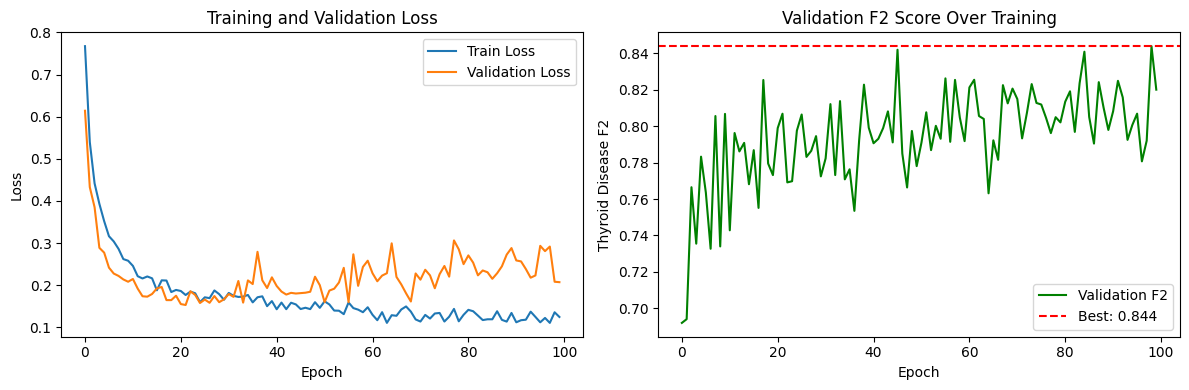

In [ ]:
import matplotlib.pyplot as pltbest_val_f2 = max(val_f2s)fig, axes = plt.subplots(1, 2, figsize=(12, 4))axes[0].plot(train_losses, label='Train Loss')axes[0].plot(val_losses, label='Validation Loss')axes[0].set_xlabel('Epoch')axes[0].set_ylabel('Loss')axes[0].set_title('Training and Validation Loss')axes[0].legend()axes[1].plot(val_f2s, label='Validation F2', color='green')axes[1].axhline(y=best_val_f2, color='red', linestyle='--', label=f'Best: {best_val_f2:.3f}')axes[1].set_xlabel('Epoch')axes[1].set_ylabel('Thyroid Disease F2')axes[1].set_title('Validation F2 Score Over Training')axes[1].legend()plt.tight_layout()plt.show()

## evaluación with Best modelo

In [ ]:
from sklearn.metrics import classification_report, confusion_matriximport seaborn as sns# modelo is already the best checkpoint (loaded inside train_model)model.eval()with torch.no_grad():    val_outputs = model(X_val_tensor)    val_predictions = val_outputs.argmax(dim=1).numpy()print("Neural Network - Classification Report (Validation Set):")print(classification_report(    y_val_encoded, val_predictions,    target_names=label_encoder.classes_,    zero_division=0))

Neural Network - Classification Report (Validation Set):
              precision    recall  f1-score   support

hyperthyroid       0.50      0.94      0.65        31
 hypothyroid       0.55      0.98      0.70        85
    negative       1.00      0.91      0.95      1054

    accuracy                           0.91      1170
   macro avg       0.68      0.94      0.77      1170
weighted avg       0.95      0.91      0.92      1170



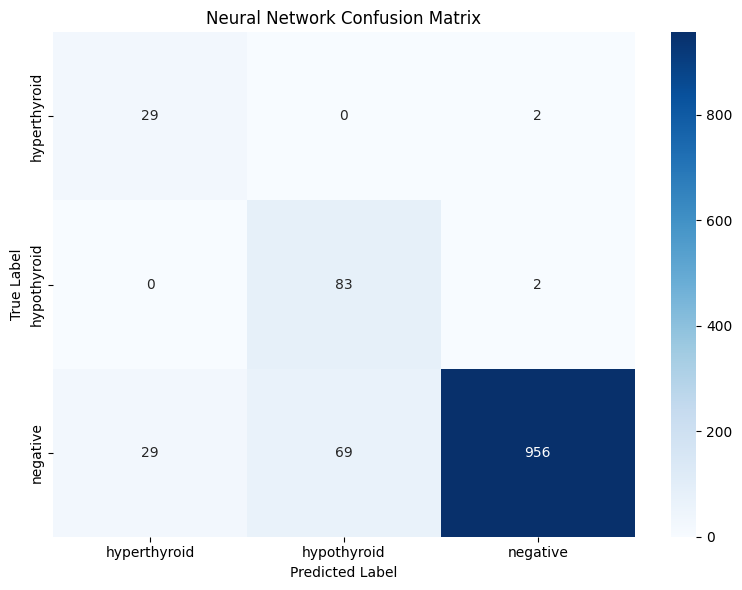

In [ ]:
cm = confusion_matrix(y_val_encoded, val_predictions)plt.figure(figsize=(8, 6))sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',            xticklabels=label_encoder.classes_,            yticklabels=label_encoder.classes_)plt.title('Neural Network Confusion Matrix')plt.ylabel('True Label')plt.xlabel('Predicted Label')plt.tight_layout()plt.show()

## Cross-validación

The single-split resultado above depends on the particular random split chosen. To get a more stable estimate — and to compare fairly with El resultados in notebooks 03 and 04 — we run **5-fold stratified cross-validación**, reusing `train_model()` for each fold.The key difference from sklearn cross-validación: we must re-fit the preprocesaror inside each fold on the entrenamiento fold only, to avoid Datos leakage from the validación fold.Note: each fold uses 50 epochs (vs. 100 Para el single-split run) to keep execution time reasonable.

In [ ]:
import warningsfrom sklearn.model_selection import StratifiedKFoldstratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)cv_f2_scores: list[float] = []for fold_idx, (train_idx, val_idx) in enumerate(stratified_cv.split(X_train_full, y_train_full_encoded)):    X_fold_train = X_train_full.iloc[train_idx]    X_fold_val = X_train_full.iloc[val_idx]    y_fold_train = y_train_full_encoded[train_idx]    y_fold_val = y_train_full_encoded[val_idx]    # Fit the preprocessor on the entrenamiento fold only (no fuga de datos).    # Unknown categories in the validación fold are encoded as zeros (handle_unknown='ignore'),    # which is intentional — sklearn still emits a UserWarning for this, so we suppress it.    fold_preprocessor = get_zero_imputation_with_flags_pipeline()    with warnings.catch_warnings():        warnings.filterwarnings("ignore", message="Found unknown categories", category=UserWarning)        X_fold_train_proc = fold_preprocessor.fit_transform(X_fold_train)        X_fold_val_proc = fold_preprocessor.transform(X_fold_val)    X_fold_train_t = torch.tensor(X_fold_train_proc.astype(np.float32))    y_fold_train_t = torch.tensor(y_fold_train, dtype=torch.long)    X_fold_val_t = torch.tensor(X_fold_val_proc.astype(np.float32))    y_fold_val_t = torch.tensor(y_fold_val, dtype=torch.long)    fold_model, _, _, fold_f2s = train_model(        X_fold_train_t, y_fold_train_t,        X_fold_val_t, y_fold_val_t,        n_features=n_features,        n_classes=n_classes,        num_epochs=50,  # fewer epochs per fold for speed    )    fold_best_f2 = max(fold_f2s)    cv_f2_scores.append(fold_best_f2)    print(f"  Fold {fold_idx + 1}: F2 = {fold_best_f2:.3f}")cv_f2_arr = np.array(cv_f2_scores)print(f"\nNeural Network - Thyroid Disease F2 Score (5-fold CV)")print(f"  Per-fold scores: {cv_f2_arr.round(3)}")print(f"  Mean: {cv_f2_arr.mean():.3f} (+/- {cv_f2_arr.std() * 2:.3f})")

  Fold 1: F2 = 0.830
  Fold 2: F2 = 0.832
  Fold 3: F2 = 0.870
  Fold 4: F2 = 0.847
  Fold 5: F2 = 0.854

Neural Network - Thyroid Disease F2 Score (5-fold CV)
  Per-fold scores: [0.83  0.832 0.87  0.847 0.854]
  Mean: 0.847 (+/- 0.030)


## Conclusions

**Key observations:**- The zero-imputación-with-flags strategy lets the network learn missingness patterns explicitly- **clase-weighted pérdida** (`CrossEntropyLoss(weight=...)`) is essential for high disease recall — without it, the majority "negative" clase dominates entrenamiento — exactly the same problem solved by `sample_weight` in XGBoost (notebook 04)- entrenamiento requires more manual setup than sklearn estimators: architecture choice, pérdida función, optimizer, and a custom entrenamiento bucle**Redes Neuronales vs. tree ensembles on tabular Datos:**For structured/tabular Datos with a moderate number of samples, tree ensembles typically match or outperform Redes Neuronales. The cross-validación resultados across the project confirm this:| modelo | CV F2 Score | Notes ||-------|-------------|-------|| Logistic regresión | ~0.60 | Simple linear baseline || random forest | ~0.81 | Strong non-linear baseline || XGBoost (unweighted) | ~0.85 | Sequential boosting || XGBoost (weighted) | ~0.88 | clase weights fix entrenamiento objective || red neuronal | see CV above | More setup, no consistent gain |Redes Neuronales excel at **unstructured Datos** (images, texto, sequences) and **very large Conjunto de datoss** where deep representations provide a genuine advantage. For well-structured tabular Datos with hundreds to thousands of samples, the added complexity rarely pays off.**Trade-offs:**| Aspect | Redes Neuronales | Tree Ensembles ||--------|-----------------|----------------|| Valores Faltantes | Requires explicit handling | Native (XGBoost) || Escalado de Características | Required | Not required || clase imbalance | `CrossEntropyLoss(weight=...)` | `sample_weight` in `fit()` || entrenamiento setup | Manual bucle, many choices | Single `fit()` call || Interpretability | Black box | característica importance available || Tabular rendimiento | Often comparable or worse | Generally better |